In [2]:
!pip install statsmodels

In [3]:
!pip install wquantiles

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean #Media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
estado=pd.read_csv("/content/drive/MyDrive/state.csv")
estado.head(10)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


In [7]:
estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


In [6]:
estado.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


In [8]:
estado["Population"].mean()

np.float64(6162876.3)

In [9]:
trim_mean(estado.Population, 0.1)

np.float64(4783697.125)

In [10]:
estado.Population.median()

4436369.5

In [11]:
np.average(estado["Murder.Rate"],weights=estado["Population"])

np.float64(4.445833981123393)

In [12]:
wquantiles.median(estado["Murder.Rate"],weights=estado["Population"])

np.float64(4.4)

<Axes: >

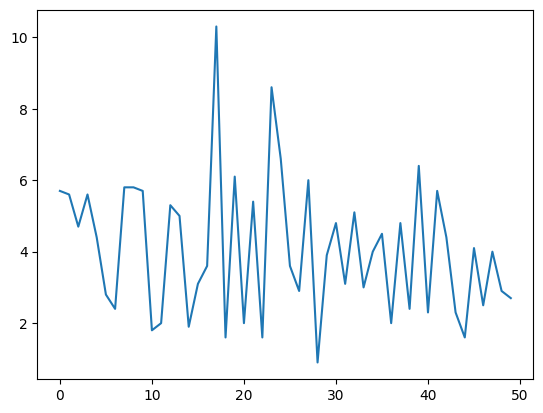

In [13]:
estado["Murder.Rate"].plot.line()

<Axes: >

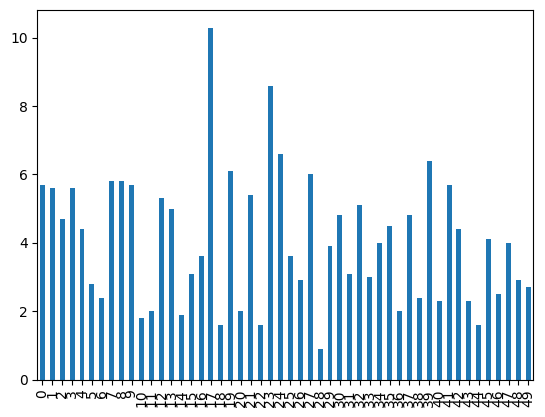

In [14]:
estado["Murder.Rate"].plot.bar()

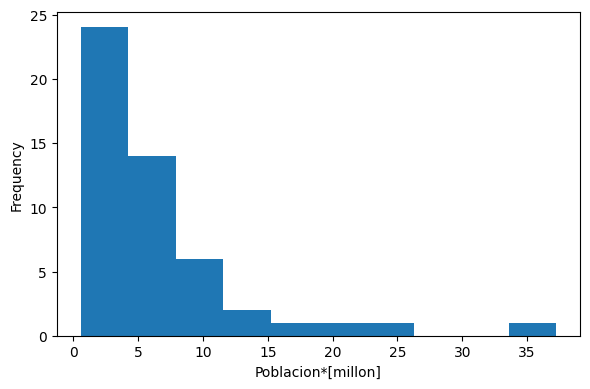

In [15]:
ax=(estado.Population/1_000_000).plot.hist(figsize=(6,4))
ax.set_xlabel("Poblacion*[millon]")

plt.tight_layout()
plt.show()

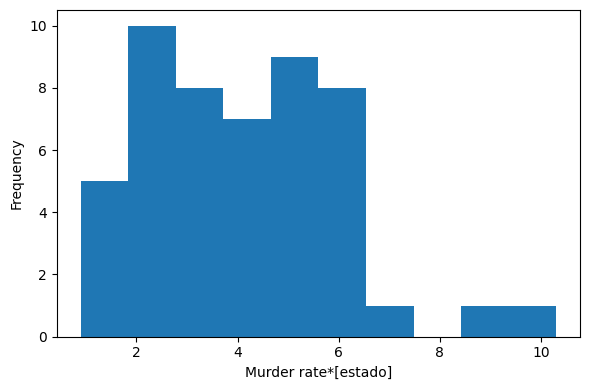

In [16]:
ax=(estado["Murder.Rate"]).plot.hist(figsize=(6,4))
ax.set_xlabel("Murder rate*[estado]")

plt.tight_layout()
plt.show()

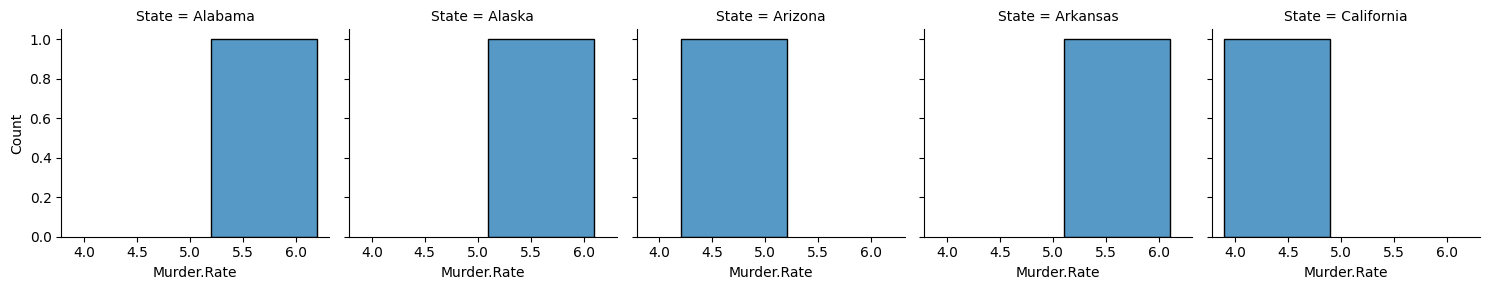

In [19]:
analisis=estado.head()
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

Tarea: graficar todos los estados en 5 en 5

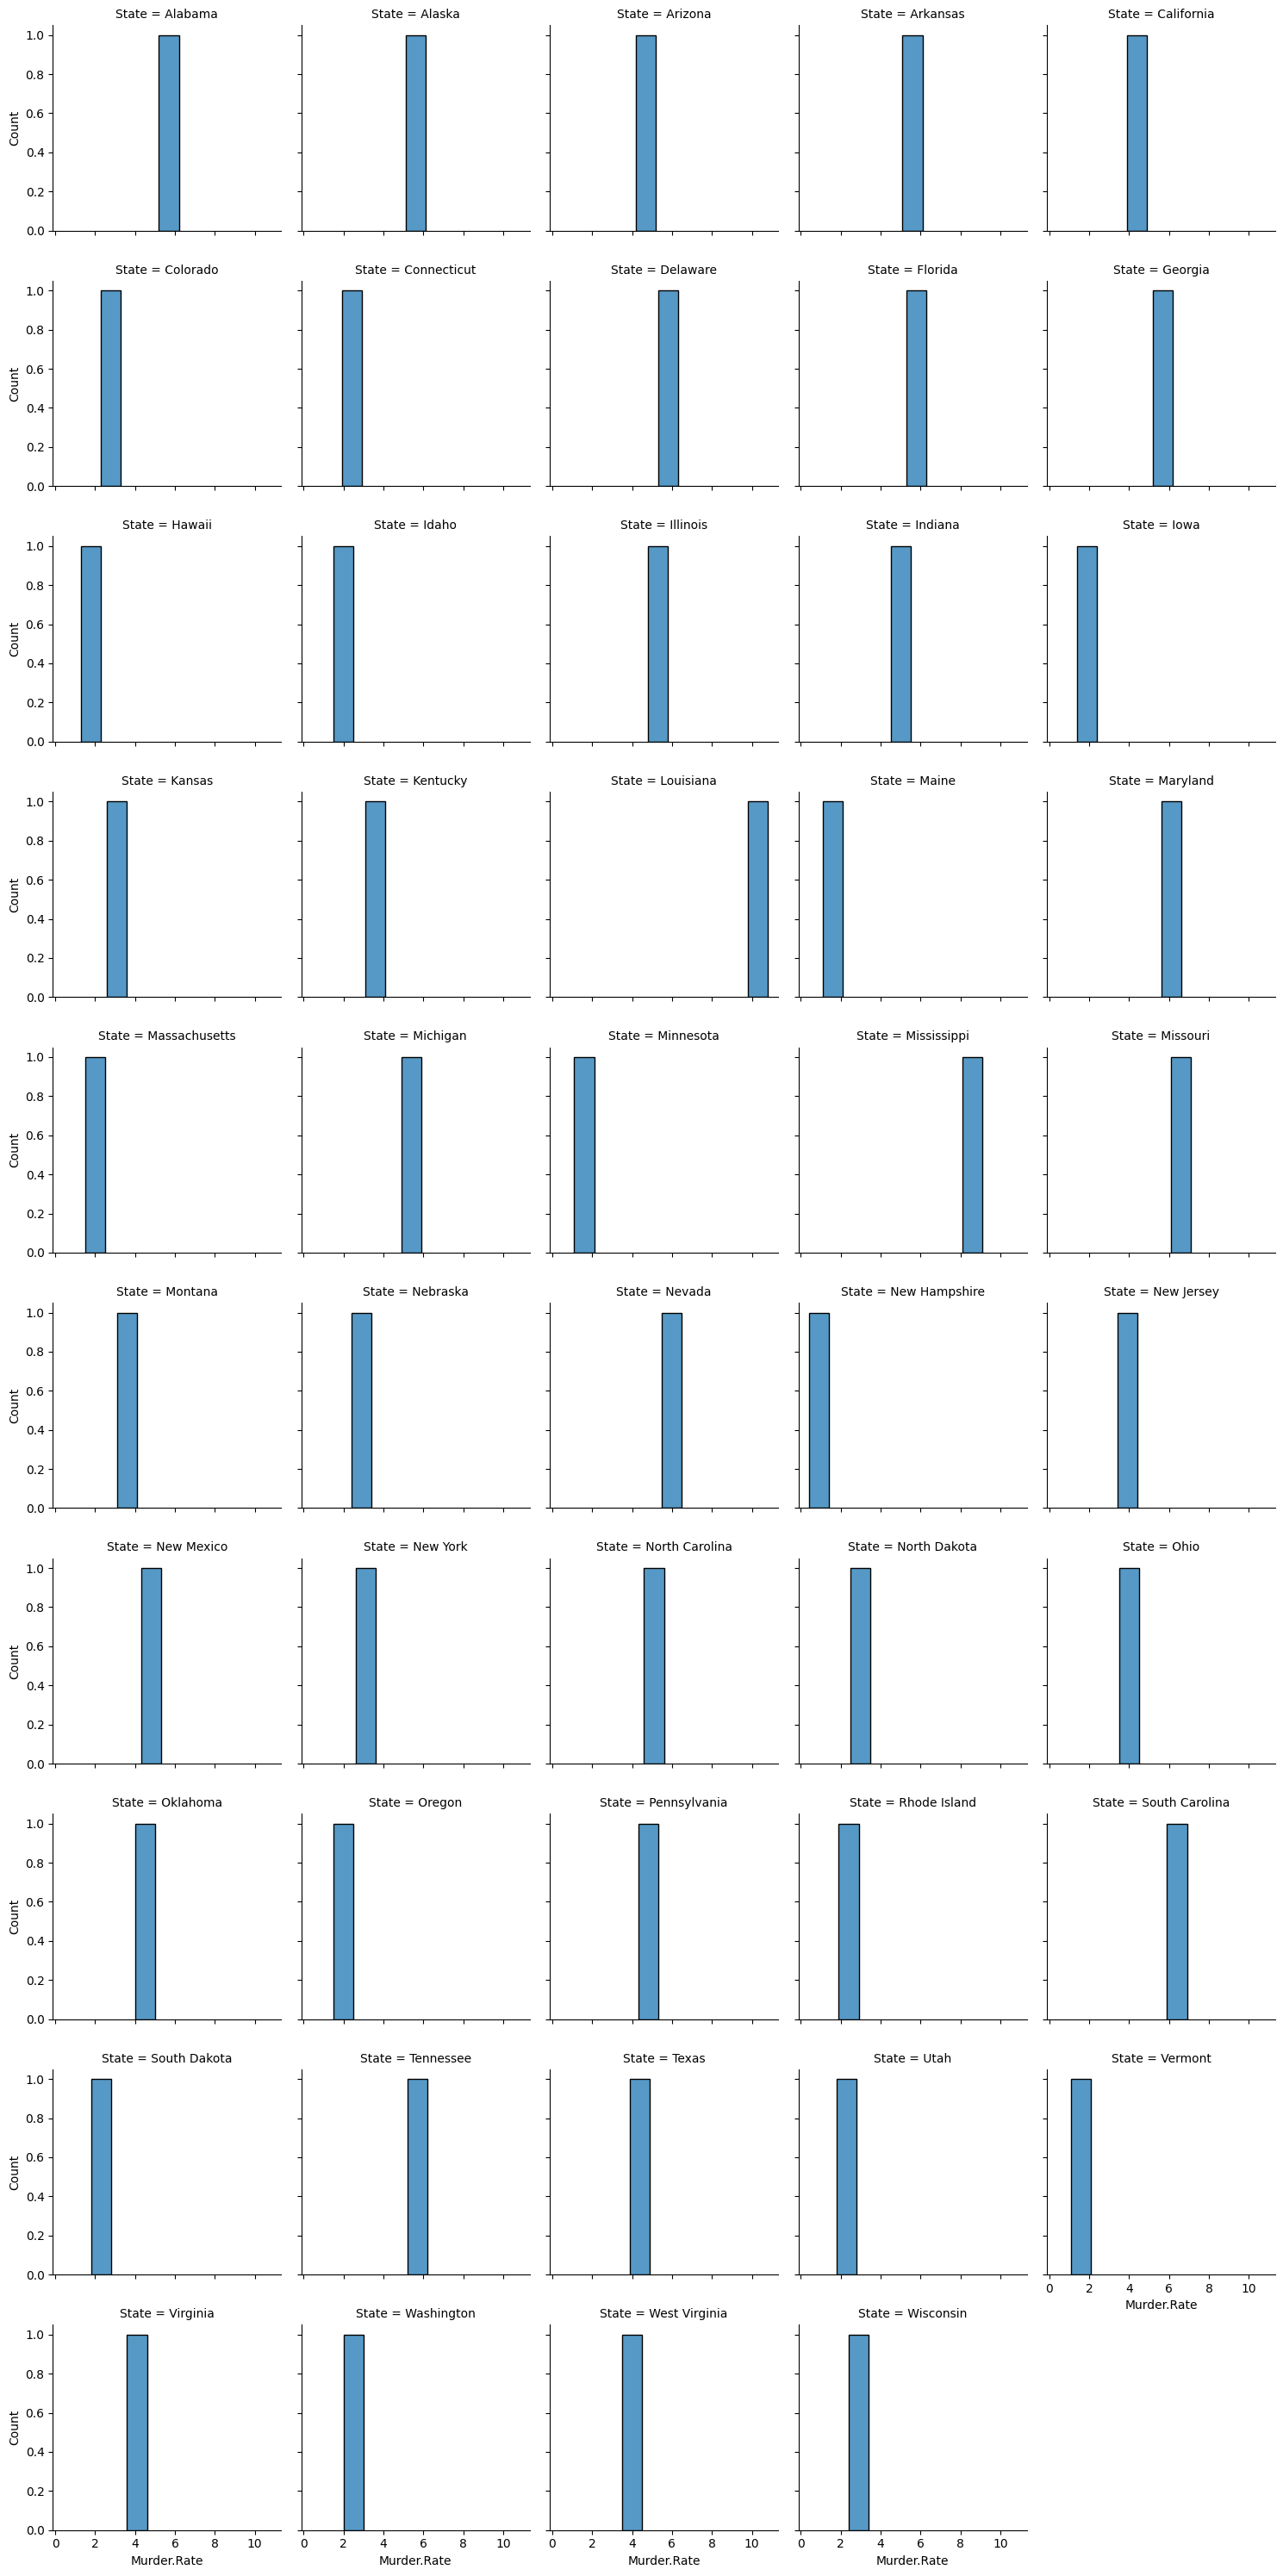

In [21]:
analisis = estado.head(49)

g = sns.FacetGrid(analisis, col="State", col_wrap=5)

g.map(sns.histplot, "Murder.Rate", bins=1)

In [22]:
estado["Murder.Rate"].quantile(0.75)-estado["Murder.Rate"].quantile(0.25)

np.float64(3.125)

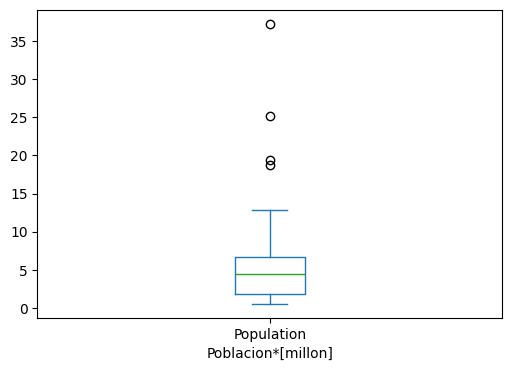

In [23]:
ax=(estado.Population/1_000_000).plot.box(figsize=(6,4))
ax.set_xlabel("Poblacion*[millon]")


plt.show()

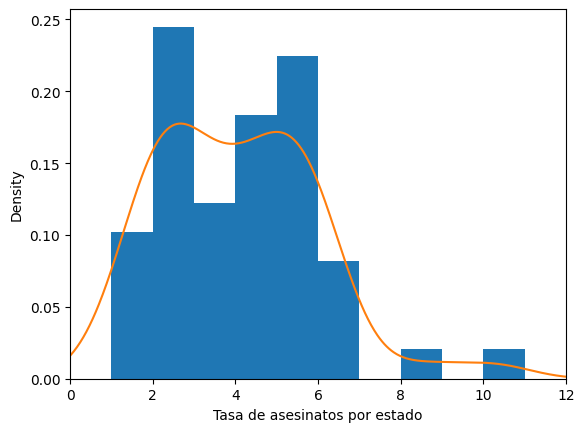

In [24]:
ax=(estado["Murder.Rate"]).plot.hist(density=True, xlim=[0,12],bins=range(1,12))
estado["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Tasa de asesinatos por estado")

plt.show()

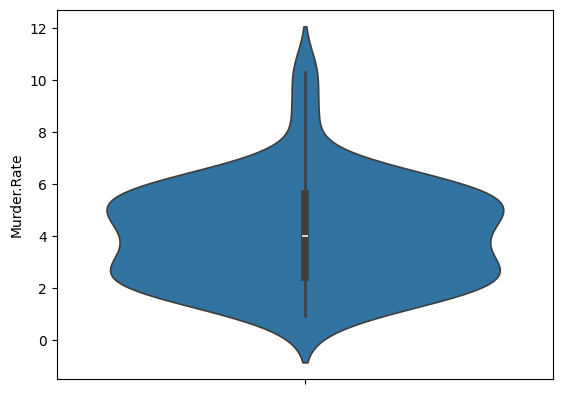

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

analisis = estado.head(49)

sns.violinplot(data=analisis, y="Murder.Rate")

plt.show()

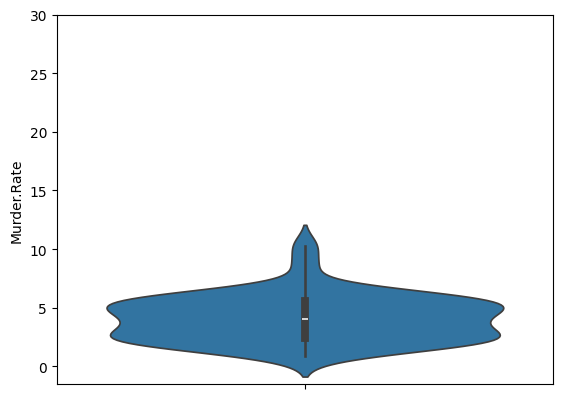

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

analisis = estado.head(49)

sns.violinplot(data=analisis, y="Murder.Rate")

plt.yticks(range(0, 31, 5))

plt.show()